# The rewrite rules, one example each

Every rule of the reduction machine with one drawn example. The rules live in
three registries:

* `CIRCULAR_RULES` — the structural rules C1–C20 (`reduce_circular`): dot and
  trivalent absorption, the merge family, the two-colour braid rules, the
  big-node family. Each one lowers `circular_weight`.
* `CIRCULAR_REGION_RULES` — the same relations, matched on the boundary word
  of a region instead of on node shapes.
* `CIRCULAR_STEPS` — the steps of `reduce_to_circular_leave`: scalar
  extraction, fusion, the structural rules, parallel merges, the Zamolodchikov
  rules and D4.

The examples are not hand-made. Reducing the double leaves of a few word pairs
produces every intermediate diagram; for each rule the first diagram it fires
on is kept and drawn as the image equation `D → c₁·D₁ + c₂·D₂ + …`.

In [1]:
using DiagrammaticHecke
debug_circular(true)   # arm, region and leaf numbers in every picture

true

## 1. The registries

In [2]:
println("CIRCULAR_RULES:        ", join(string.(r.name for r in CIRCULAR_RULES), ", "))
println("CIRCULAR_REGION_RULES: ", join(string.(r.name for r in CIRCULAR_REGION_RULES), ", "))
println("CIRCULAR_STEPS:        ", join(string.(first.(CIRCULAR_STEPS)), ", "))

CIRCULAR_RULES:        

needle, pitchfork, dot_walks_on, barbell, bead, mono_double, two_adjacent_merge, commutation_merge, merge, dot_into_braid, braid_back, braid_relation, two_adjacent_dots, dot_on_gen12, braid_on_gen12, gen12_on_gen12, gen12_on_gen12_null, gen12_two_edges, gen12_merge, trivalent_into_gen12, mixed_into_gen12


CIRCULAR_REGION_RULES: needle, braid_back_region, braid_relation_region


CIRCULAR_STEPS:        scalars, fusion, circular_rules, parallel_merge, 2parallel, zamo, d4, rex_fusion, dot_fusion


## 2. Harvesting examples

`rule_examples` runs the driver loop of `reduce_circular` by hand on every
double leaf of the given word pairs and records, per rule name, the first
diagram the rule fires on together with the result. The morphism is kept as
well: it supplies the boundary marking for the pictures.

In [3]:
function rule_examples(pairs; rules = CIRCULAR_RULES, degree_max = 2, extra = [])
    found = Dict{Symbol,Tuple{CircularDecorated,CircularComboR,Any}}()
    inputs = Any[circular_morphism(d.morphism) for (x, y) in pairs
                 for d in double_leaves(x, y) if d.degree <= degree_max]
    append!(inputs, extra)
    for fm in inputs
        combo = CircularComboR(circular_decorated(fm.graph))
        for _ in 1:200
            next = CircularComboR(); fired = false
            for (dd, coeff) in pairs_of(combo)
                hit = nothing
                for r in rules
                    res = r.apply(dd)
                    res === nothing && continue
                    haskey(found, r.name) || (found[r.name] = (dd, res, fm))
                    hit = res; break
                end
                next = next + coeff * (hit === nothing ? CircularComboR(dd) : hit)
                hit === nothing || (fired = true)
            end
            combo = next
            fired || break
        end
    end
    return found
end

pairs = [([1,2,1], [1,2,1]), ([1,2,1,3], [1,2,1,3]), ([2,1,3,2], [2,1,3,2]),
         ([1,2,1,3,2], [1,2,1,3,2]), ([1,2,1,3,2,1], [1,2,1,3,2,1])]
examples = rule_examples(pairs)
println("rules with an example: ", join(sort(string.(keys(examples))), ", "))

rules with an example: braid_back, braid_relation, gen12_merge, merge, pitchfork, trivalent_into_gen12, two_adjacent_merge


## 3. The structural rules C1–C20

One row per rule, in registry order: the diagram on the left, the sum it is
replaced by on the right.

pitchfork 9 nodes 2 Braids → 0
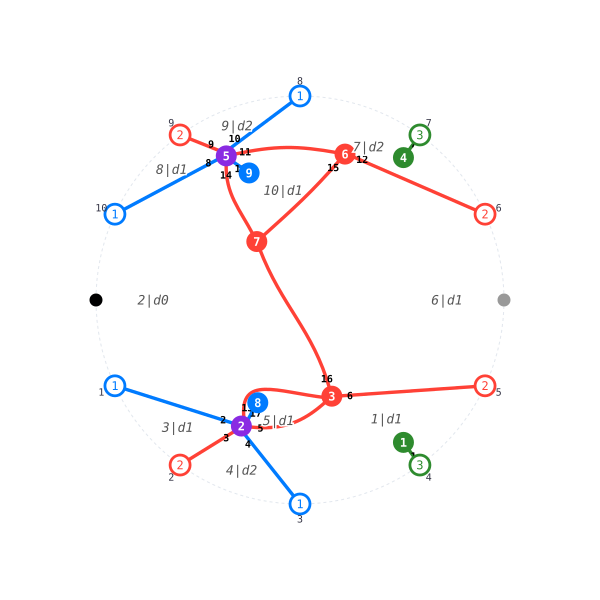

two_adjacent_merge 8 nodes → 7 nodes
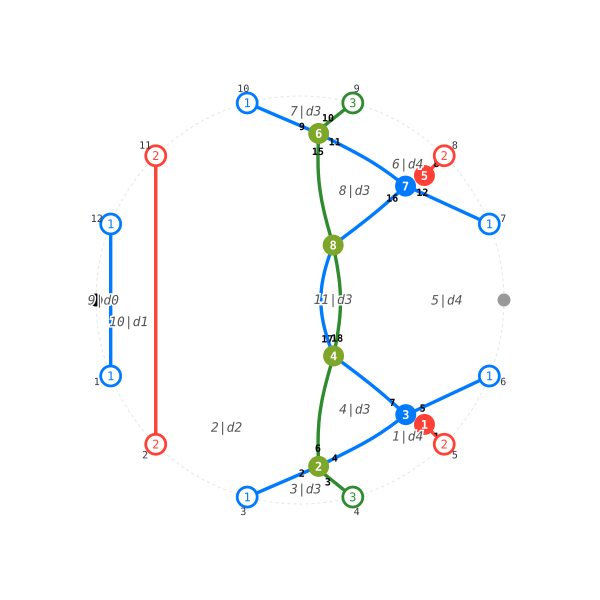
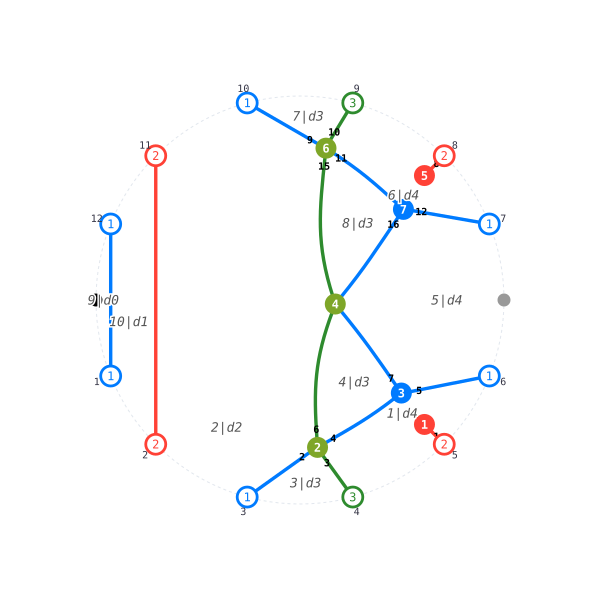

merge 4 nodes → 3 nodes
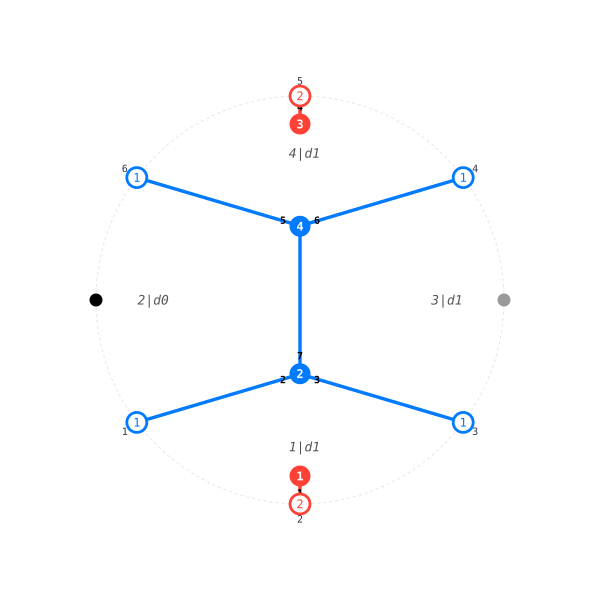
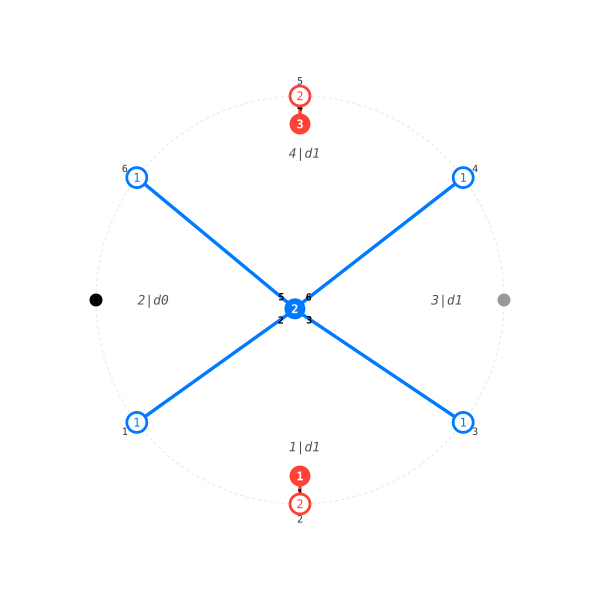

braid_back 4 nodes 2 Braids → 2 nodes + 6 nodes
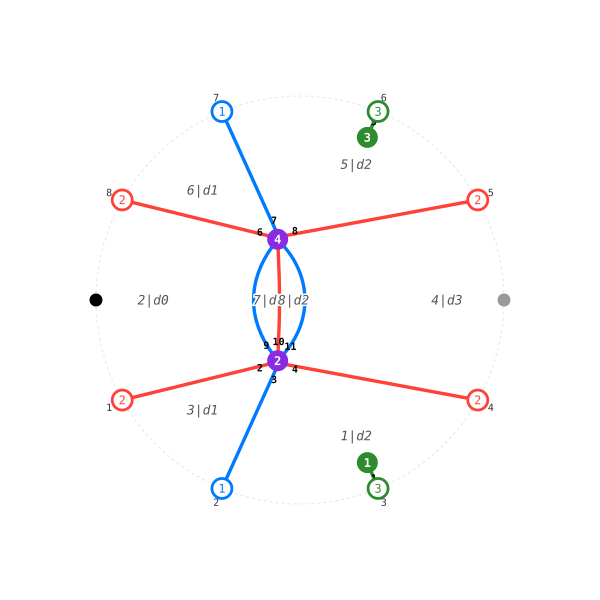
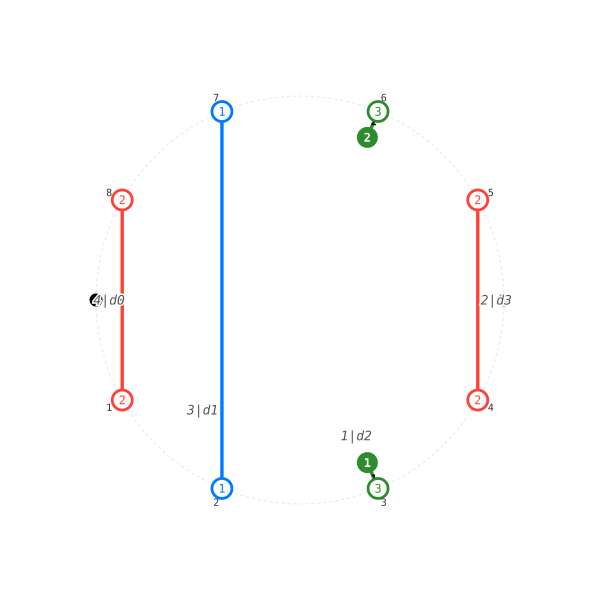
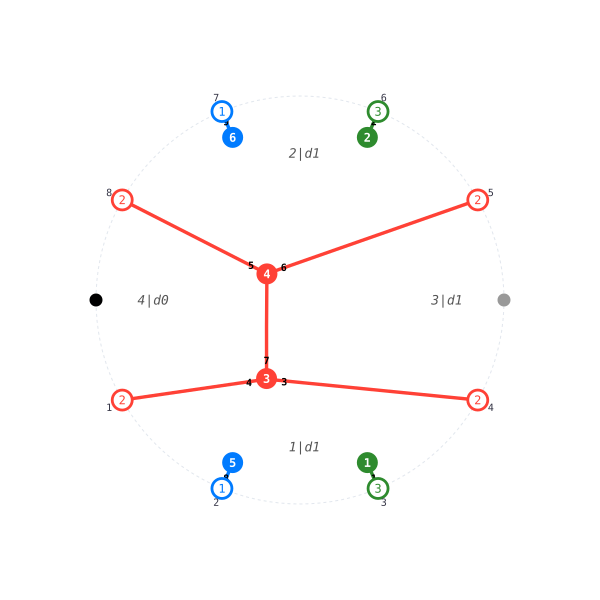

braid_relation 5 nodes 2 Braids → 5 nodes 1 Braid
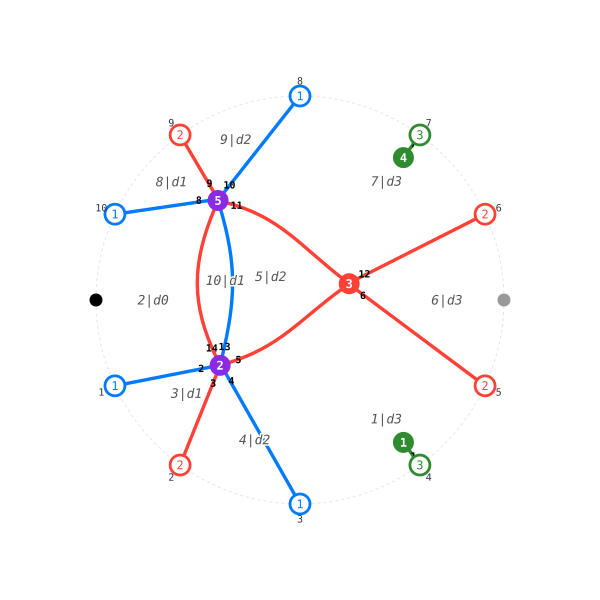
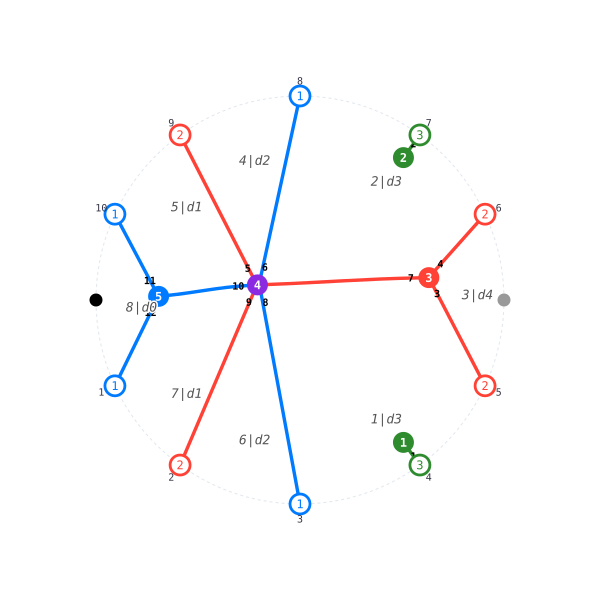

gen12_merge 6 nodes 2 Braids → 5 nodes
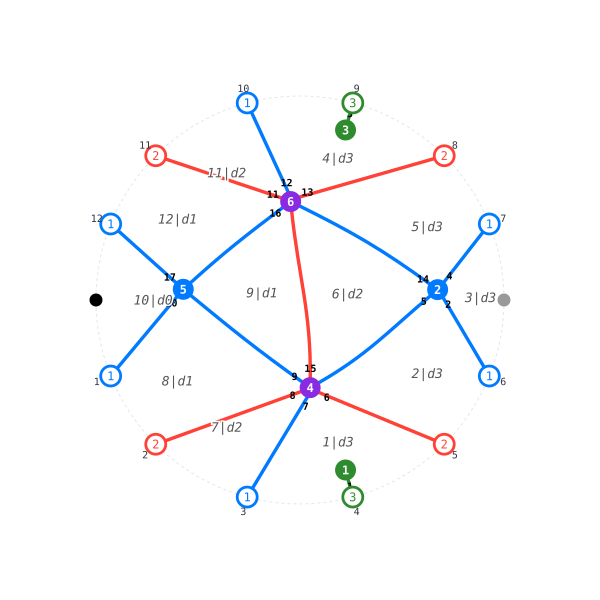
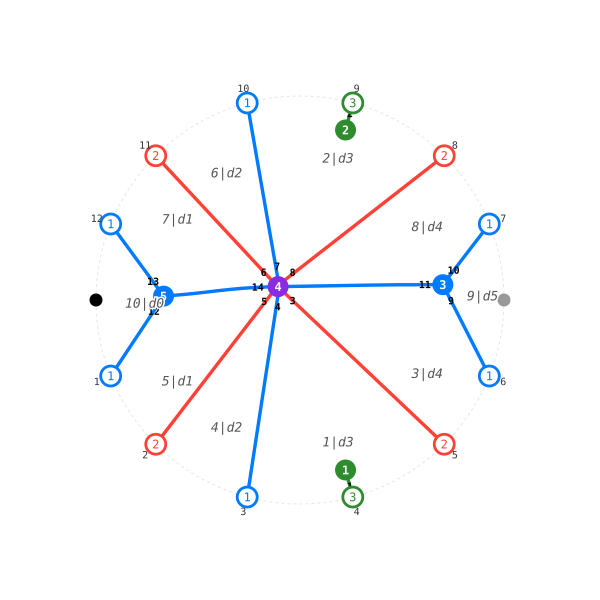

trivalent_into_gen12 5 nodes 1 Braid → 5 nodes
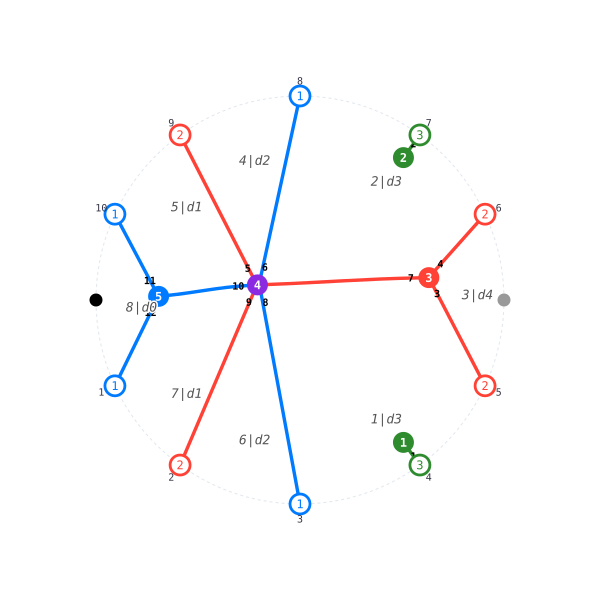
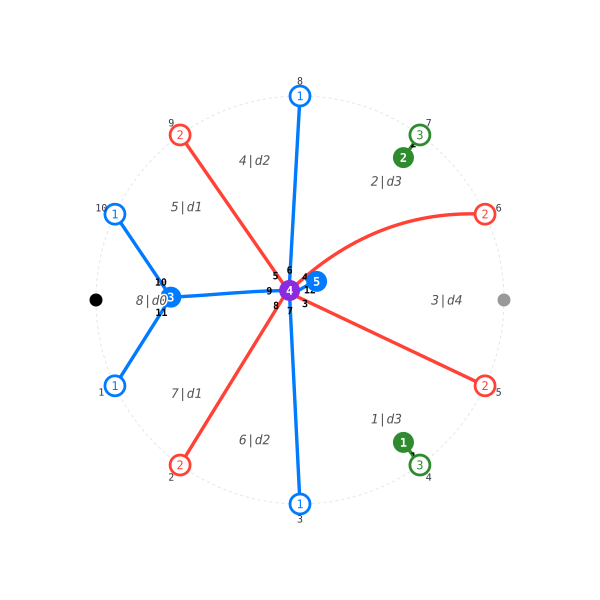

In [4]:
for r in CIRCULAR_RULES
    haskey(examples, r.name) || continue
    before, after, fm = examples[r.name]
    show_circular_step_row(before, after, fm; title = string(r.name))
end

The dot rules C2–C4 need a dot next to a trivalent or on a bigon. The named
fixtures of `diagram/Fixtures.jl` provide such diagrams.

needle 1 nodes → 0
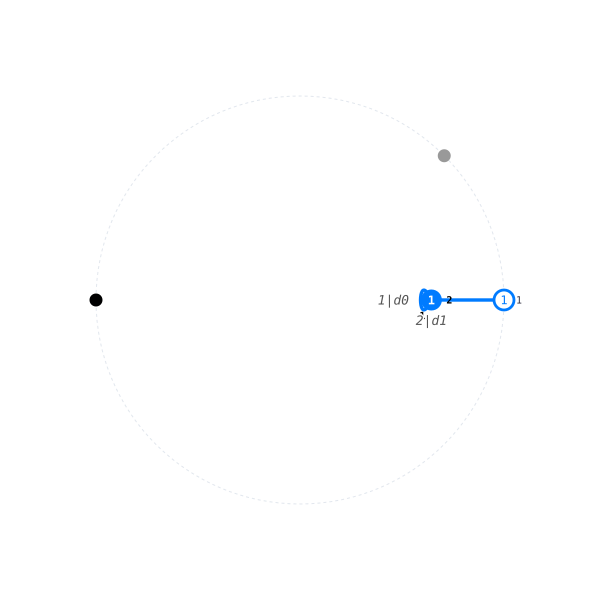

dot_walks_on 2 nodes → 1 nodes
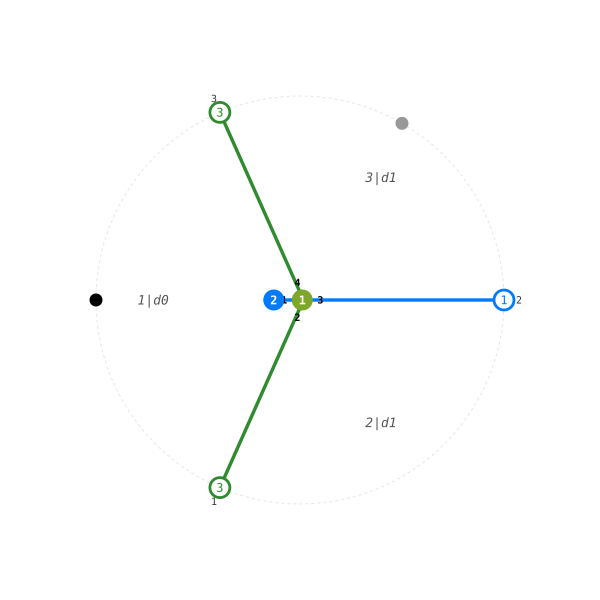
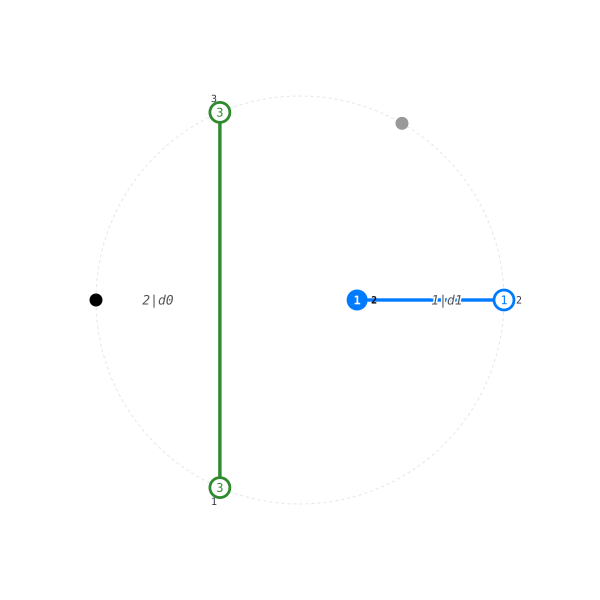

barbell 2 nodes → 0 nodes
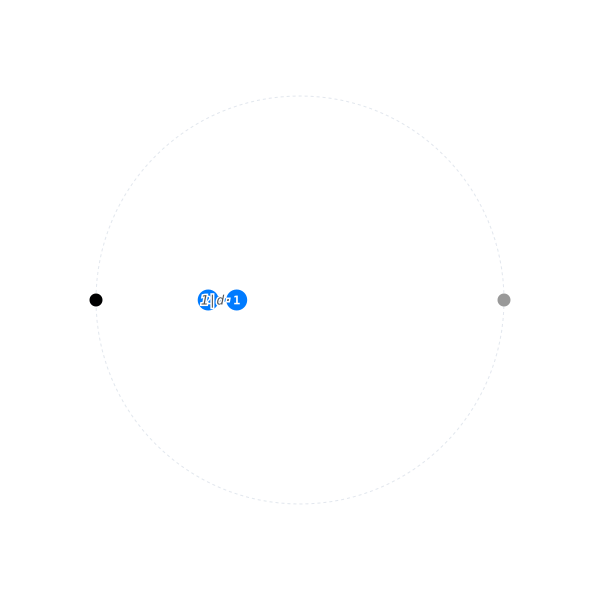
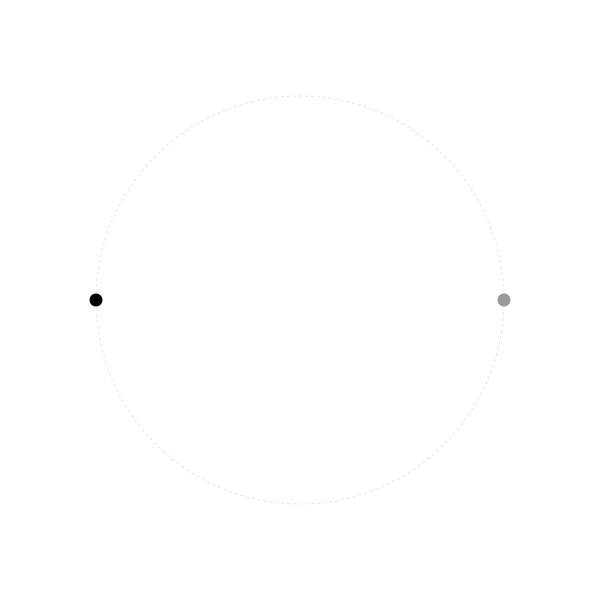

mono_double 2 nodes → 0
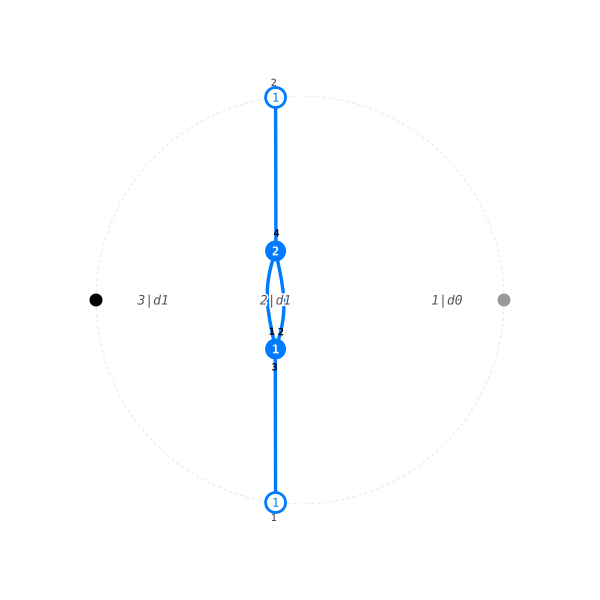

dot_into_braid 2 nodes 1 Braid → 1 nodes + 3 nodes
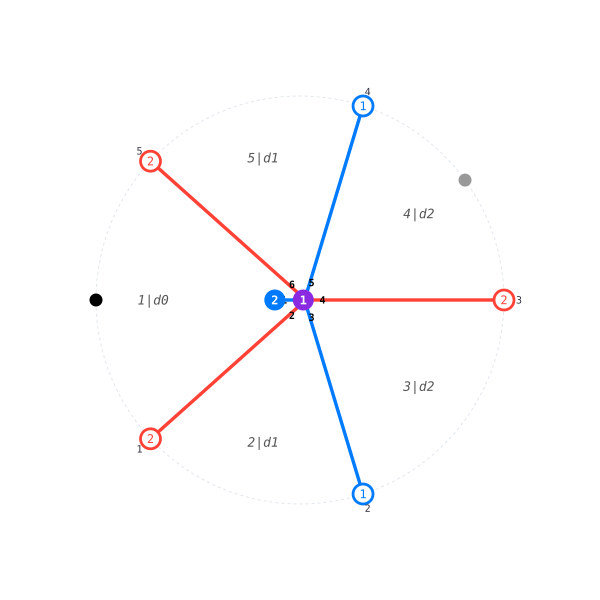
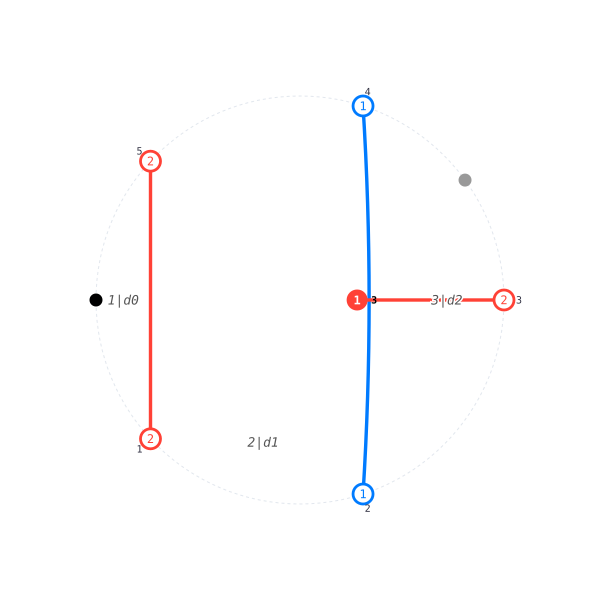
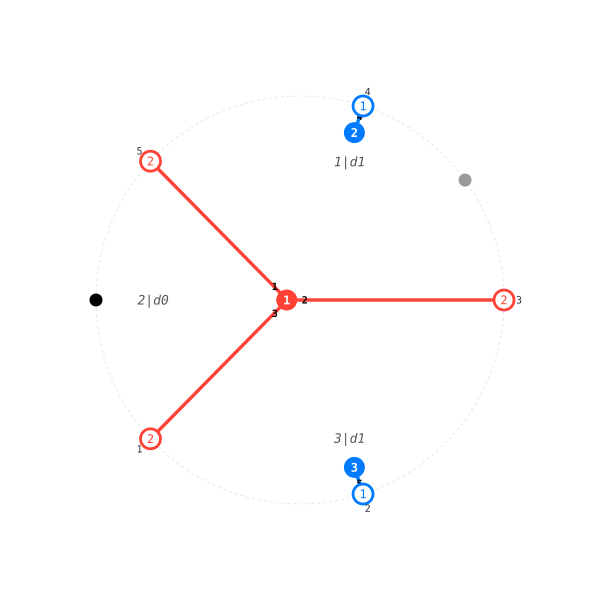

Dict{Symbol, Tuple{CircularDecorated, CircularComboR, Any}} with 12 entries:
  :pitchfork            => (CircularDecorated(CircularGraph(1121322312, 9 nodes…
  :trivalent_into_gen12 => (CircularDecorated(CircularGraph(1121322312, 5 nodes…
  :braid_relation       => (CircularDecorated(CircularGraph(1121322312, 5 nodes…
  :gen12_merge          => (CircularDecorated(CircularGraph(112132112312, 6 nod…
  :dot_walks_on         => (CircularDecorated(CircularGraph(133, 2 nodes, 4 edg…
  :needle               => (CircularDecorated(CircularGraph(1, 1 nodes, 2 edges…
  :mono_double          => (CircularDecorated(CircularGraph(11, 2 nodes, 4 edge…
  :two_adjacent_merge   => (CircularDecorated(CircularGraph(112132112312, 8 nod…
  :barbell              => (CircularDecorated(CircularGraph(ε, 2 nodes, 1 edges…
  :dot_into_braid       => (CircularDecorated(CircularGraph(12122, 2 nodes, 6 e…
  :braid_back           => (CircularDecorated(CircularGraph(12213223, 4 nodes, …
  :merge                => (Circ

In [5]:
fixtures = [unit_graph(), needle_a_graph(), needle_b_graph(), barbell_graph(),
            r3_braid_dot(), r4_braid_dot()]
more = rule_examples([]; extra = [CircularMorphismGraph(circular(g), 0, 0) for g in fixtures])
for r in CIRCULAR_RULES
    haskey(more, r.name) && !haskey(examples, r.name) || continue
    before, after, fm = more[r.name]
    show_circular_step_row(before, after, fm; title = string(r.name))
end
merge!(examples, more)

The big-node family (C13–C20) starts from two braid nodes sharing three
edges. `general_braid_cluster(2)` is the smallest such diagram: two braids and
two trivalents, the input of C13, whose output is the 8-armed node. Dots on
that node give the inputs of C20 (two adjacent dots) and C14 (one dot).

two_adjacent_dots 3 nodes → 1 nodes 1 Braid
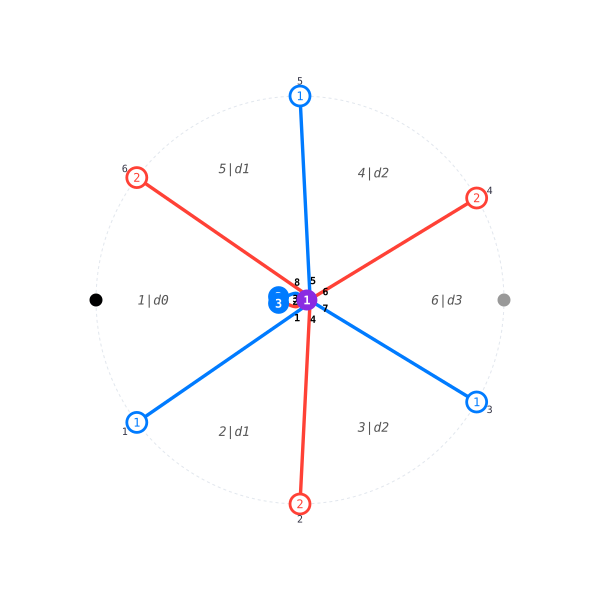
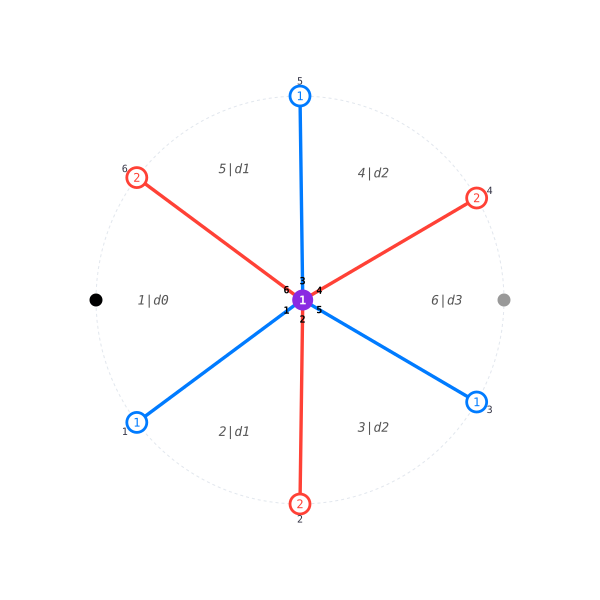

Dict{Symbol, Tuple{CircularDecorated, CircularComboR, Any}} with 13 entries:
  :pitchfork            => (CircularDecorated(CircularGraph(1121322312, 9 nodes…
  :trivalent_into_gen12 => (CircularDecorated(CircularGraph(1121322312, 5 nodes…
  :braid_relation       => (CircularDecorated(CircularGraph(1121322312, 5 nodes…
  :gen12_merge          => (CircularDecorated(CircularGraph(12121212, 4 nodes, …
  :dot_walks_on         => (CircularDecorated(CircularGraph(133, 2 nodes, 4 edg…
  :needle               => (CircularDecorated(CircularGraph(1, 1 nodes, 2 edges…
  :mono_double          => (CircularDecorated(CircularGraph(11, 2 nodes, 4 edge…
  :two_adjacent_merge   => (CircularDecorated(CircularGraph(112132112312, 8 nod…
  :barbell              => (CircularDecorated(CircularGraph(ε, 2 nodes, 1 edges…
  :dot_into_braid       => (CircularDecorated(CircularGraph(12122, 2 nodes, 6 e…
  :braid_back           => (CircularDecorated(CircularGraph(12213223, 4 nodes, …
  :merge                => (Circ

In [6]:
"The graph `g` with a dot on boundary leaf `k`."
function with_dot(g::CircularGraph, k::Int)
    lets = letters(g.word)
    nodes = vcat(copy(g.nodes), [circular_node([lets[k]])])
    dot = length(nodes)
    shift(p) = p isa Leaf ? (p.k == k ? NodePort(dot, 1) : Leaf(p.k > k ? p.k - 1 : p.k)) : p
    CircularGraph(CircularWord(vcat(lets[1:k-1], lets[k+1:end])), nodes,
                  Edge[Edge(e.colour, shift(e.a), shift(e.b)) for e in g.edges])
end

cluster = general_braid_cluster(2)
c13, _ = reduce_circular(cluster)
g8 = first(pairs_of(c13))[1].graph            # the 8-armed node
big = rule_examples([]; extra = [CircularMorphismGraph(g, 0, 0)
                                 for g in (cluster, with_dot(with_dot(g8, 1), 1))])
for r in CIRCULAR_RULES
    haskey(big, r.name) && !haskey(examples, r.name) || continue
    before, after, fm = big[r.name]
    show_circular_step_row(before, after, fm; title = string(r.name))
end
merge!(examples, big)

C14 sits behind the dot policy: a single dot on an 8-armed node is left alone
by the driver unless the policy allows it, so the rule is called directly.

dot_on_gen12 2 nodes → 2 nodes 1 Braid
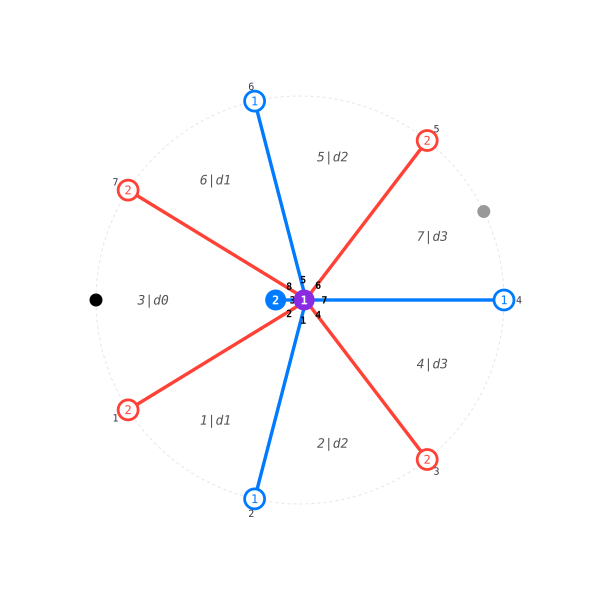
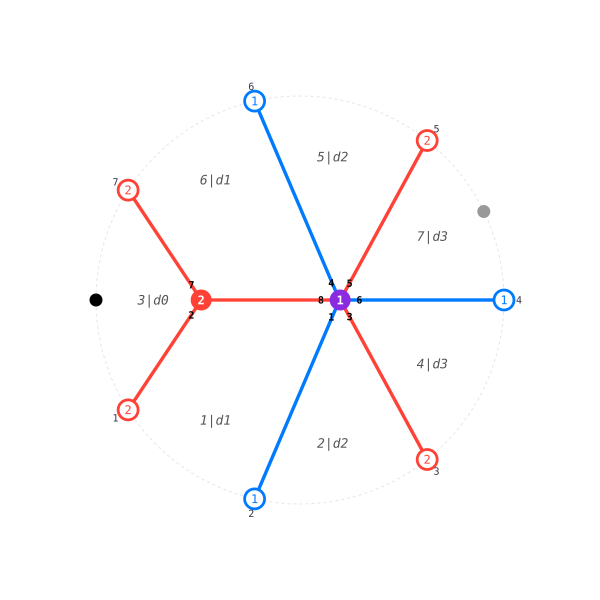

(CircularDecorated(CircularGraph(1212122, 2 nodes, 8 edges)), CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 1 term(s):
  1 · CircularDecorated(CircularGraph(1212122, 2 nodes, 8 edges)), CircularMorphismGraph(CircularGraph(1212122, 2 nodes, 8 edges), 0, 0))

In [7]:
gd = with_dot(g8, 1)
c14 = DiagrammaticHecke._lift(g -> DiagrammaticHecke._fr_dot_on_gen12(g; policy = false))
res = c14(circular_decorated(gd))
show_circular_step_row(gd, res, CircularMorphismGraph(gd, 0, 0); title = "dot_on_gen12")
examples[:dot_on_gen12] = (circular_decorated(gd), res, CircularMorphismGraph(gd, 0, 0))

Seven rules are left over: their pattern needs a many-armed node, a particular
double connection, or an unfolded preimage, and no double leaf of these short
pairs produces one. `circular/rules/CircularRuleFixtures.jl` builds a witness
for each — the planar embedding is searched, not guessed, so every diagram below
is wired and satisfies `euler == 2`.

bead 1 nodes → 0 nodes
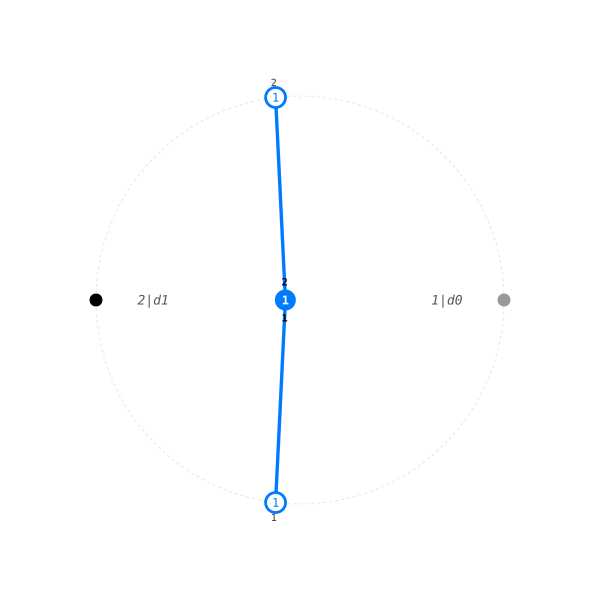
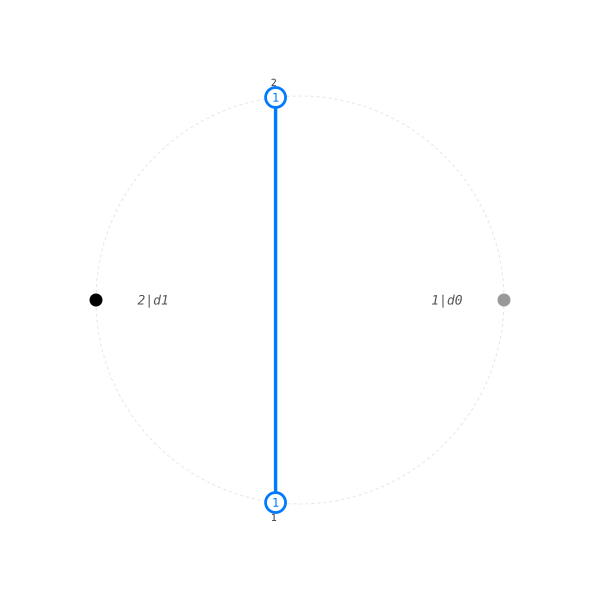

commutation_merge 2 nodes → 1 nodes
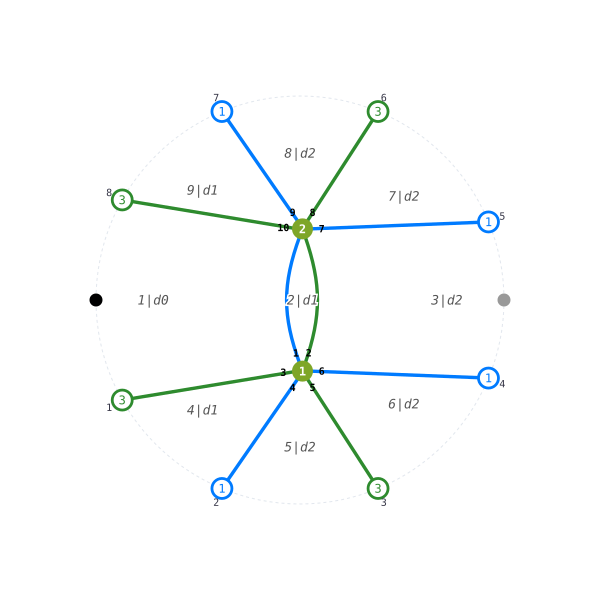
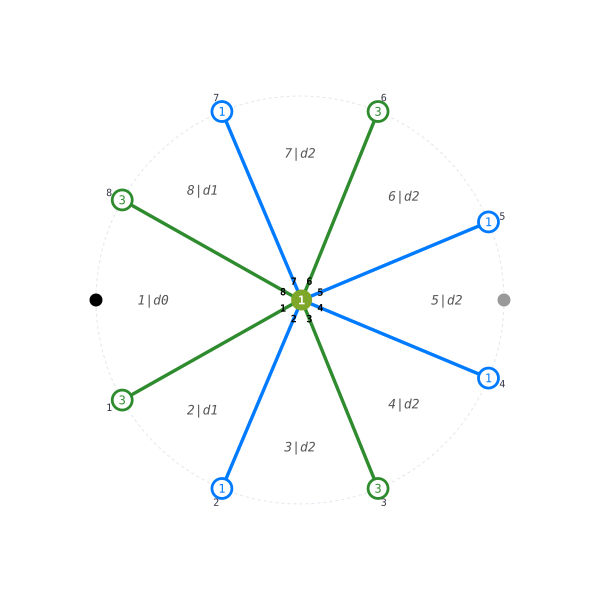

braid_on_gen12 2 nodes 1 Braid → 3 nodes 1 Braid
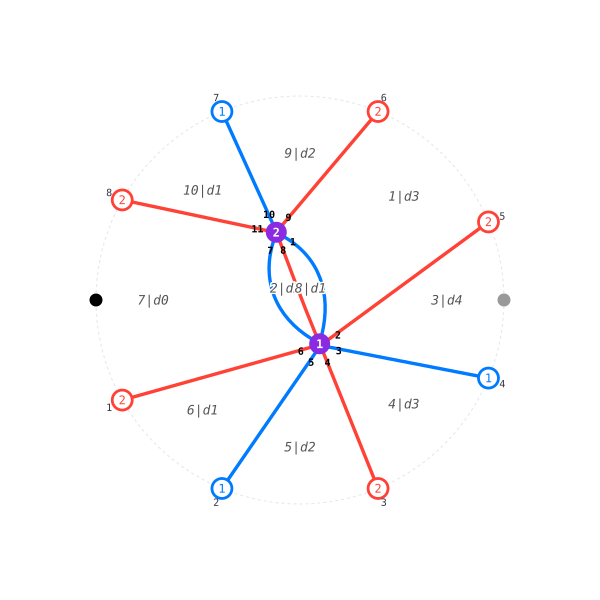
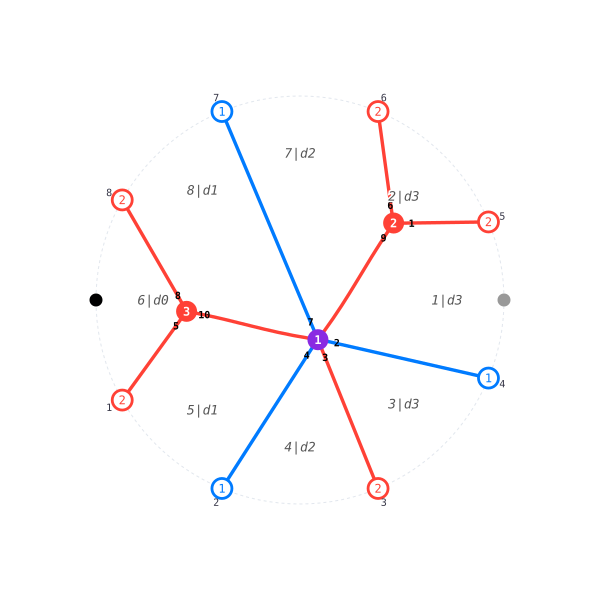

gen12_on_gen12 2 nodes → 3 nodes
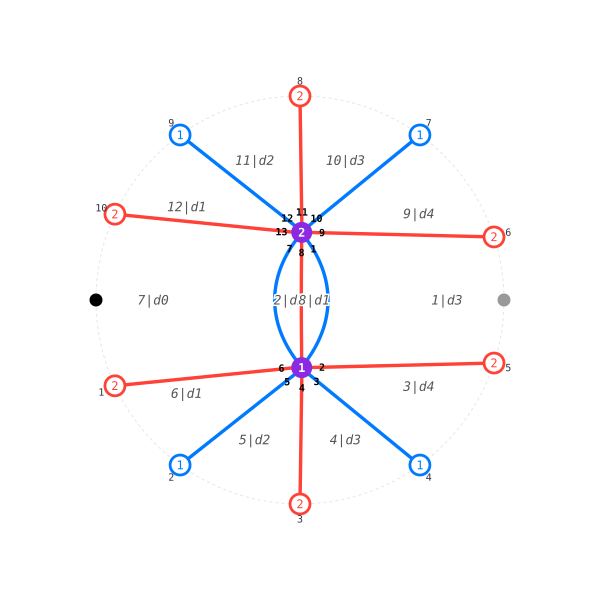
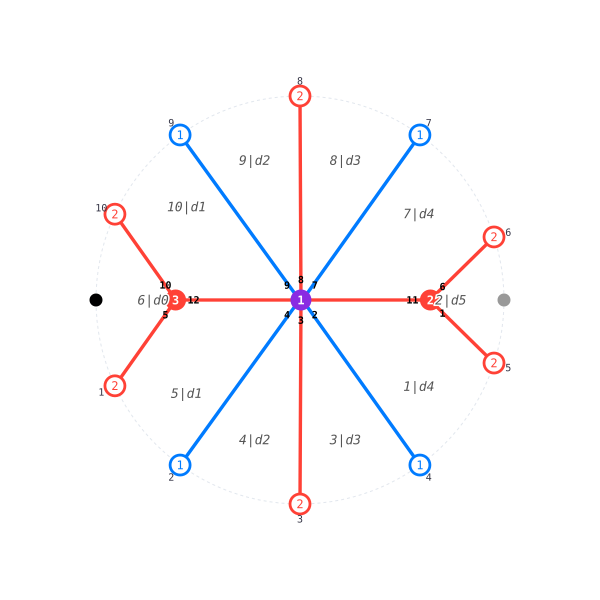

gen12_on_gen12_null 2 nodes 1 Braid → 0
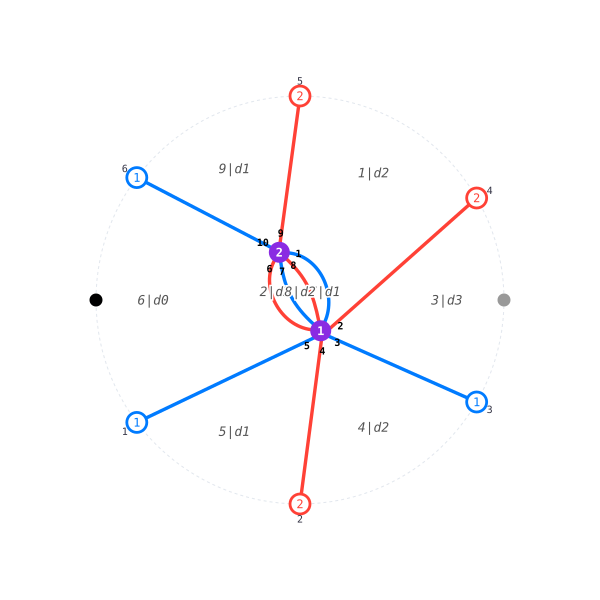

gen12_two_edges 5 nodes 2 Braids → 3 nodes
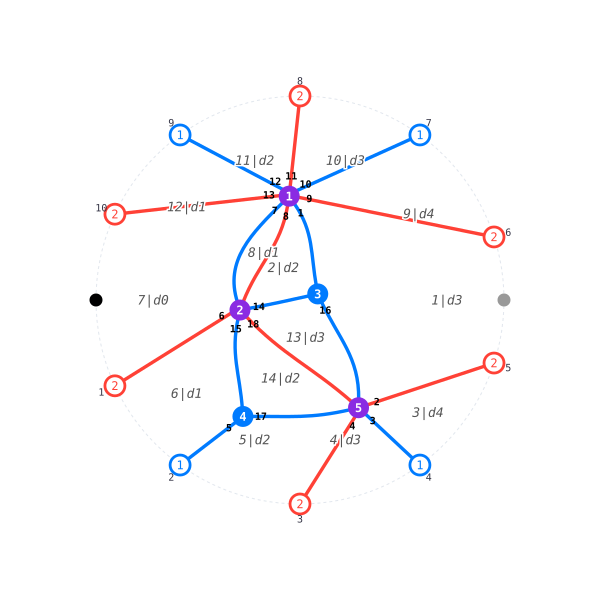
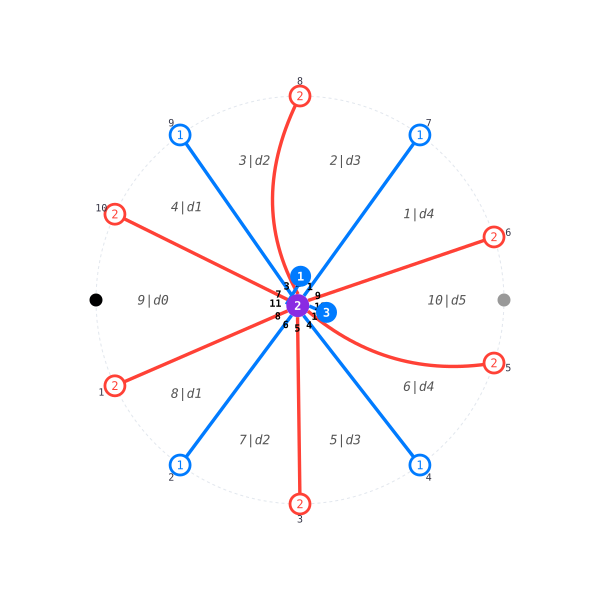

mixed_into_gen12 2 nodes 1 Braid → 4 nodes
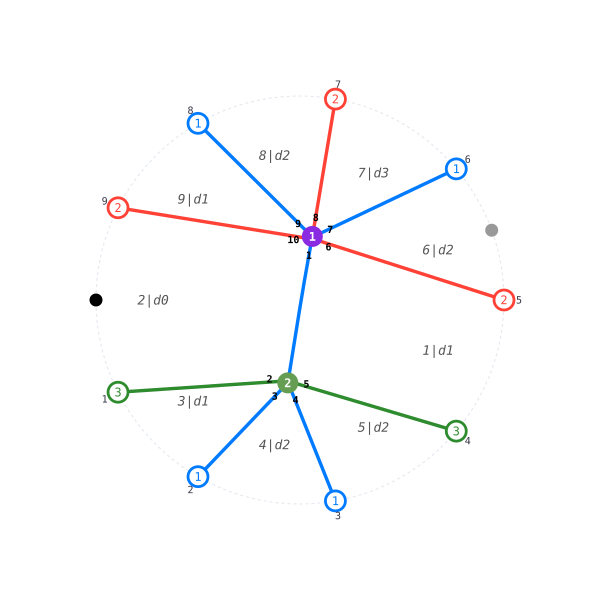
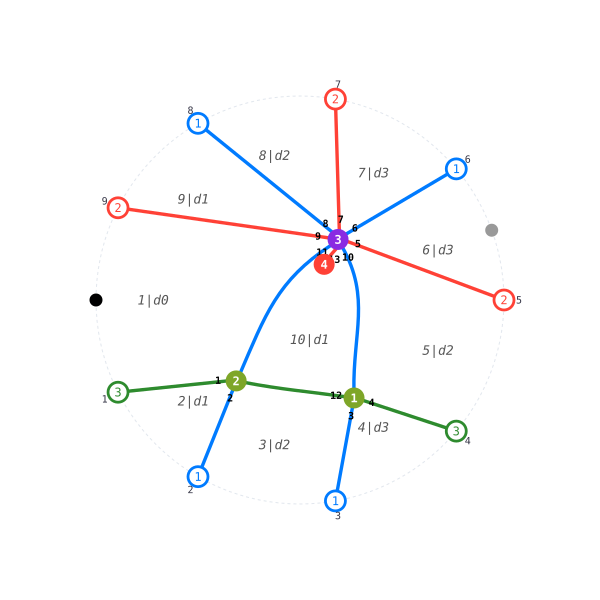

In [8]:
built = [(:bead,                circular_bead_graph()),
         (:commutation_merge,   circular_counter_joined([1,3,1,3,1,3], [3,1,3,1,3,1])),
         (:braid_on_gen12,      circular_glued_braids(8, 6, 3)),
         (:gen12_on_gen12,      circular_glued_braids(8, 8, 3)),
         (:gen12_on_gen12_null, circular_glued_braids(8, 6, 4)),
         (:gen12_two_edges,     circular_two_edge_fixture()),
         (:mixed_into_gen12,    circular_mixed_at_braid(3, (1,2), [1,3,1,1,3]))]
for (nm, g) in built
    @assert g !== nothing && euler(g) == 2 && isempty(check_wiring(g)) "$nm: not planar"
    r = only(r for r in CIRCULAR_RULES if r.name === nm)
    before = circular_decorated(g)
    after = r.apply(before)
    @assert after !== nothing "$nm does not fire on its fixture"
    show_circular_step_row(before, after, CircularMorphismGraph(g, 0, 0); title = string(nm))
    examples[nm] = (before, after, CircularMorphismGraph(g, 0, 0))
end

C22 `gen12_on_gen12_null` is the one whose right-hand side is EMPTY: four or
more shared edges force a needle, so the diagram is zero. The row above shows
the sum with no terms.

In [9]:
missing_rules = [r.name for r in CIRCULAR_RULES if !haskey(examples, r.name)]
println(isempty(missing_rules) ? "every rule in CIRCULAR_RULES has a drawn example" :
        "still without an example: $missing_rules")

every rule in CIRCULAR_RULES has a drawn example


## 4. The region rules

The region rules match the same relations on the boundary word of a region;
their examples coincide with the corresponding structural rule.

braid_back_region 4 nodes 2 Braids → 2 nodes + 6 nodes
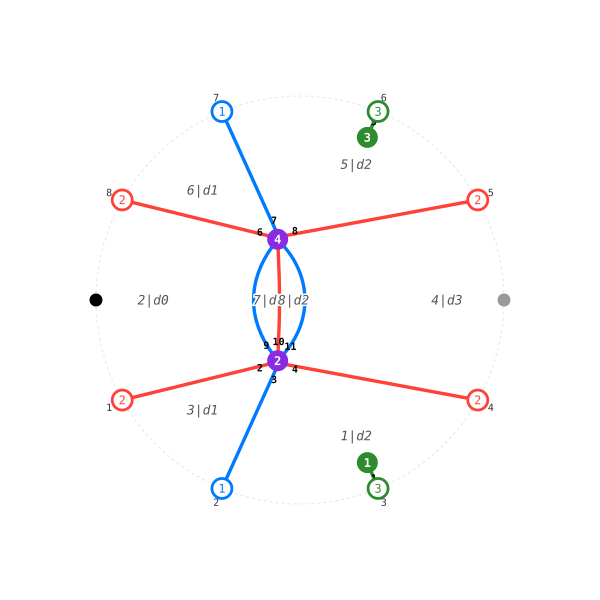
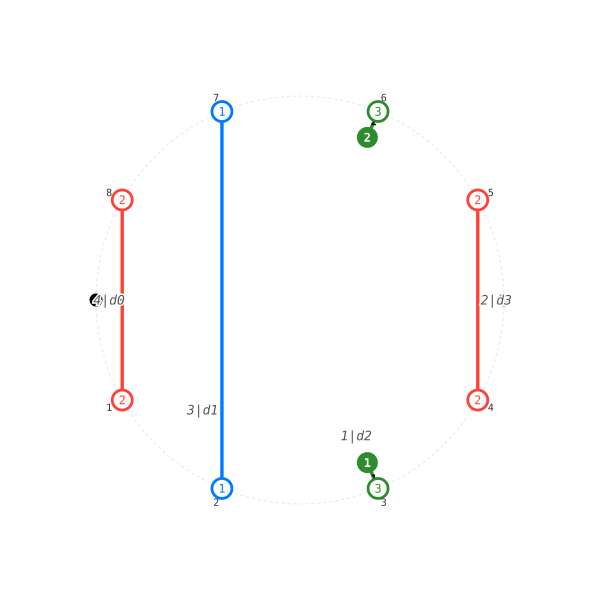
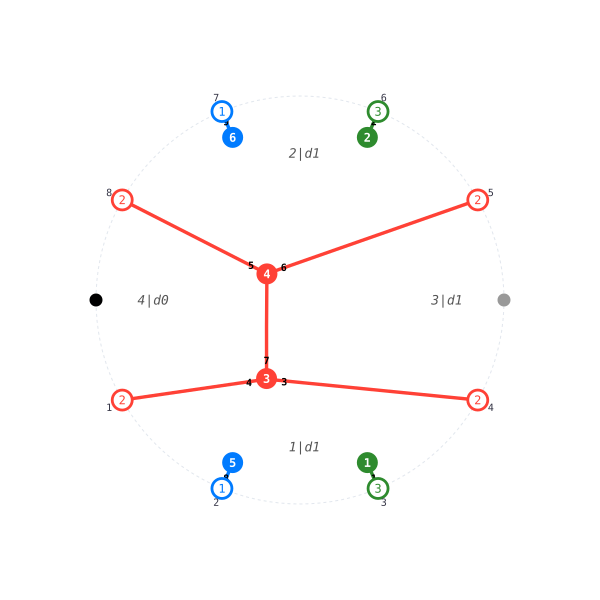

In [10]:
region_examples = rule_examples(pairs[1:3]; rules = CIRCULAR_REGION_RULES)
for r in CIRCULAR_REGION_RULES
    haskey(region_examples, r.name) || continue
    before, after, fm = region_examples[r.name]
    show_circular_step_row(before, after, fm; title = string(r.name))
end

Two of the three never come up in that harvest. `needle` matches the named
fixture `needle_b_graph` directly, and `braid_relation_region` appears part-way
through the reduction of a degree-2 double leaf over `1212` — so the diagram has
to be walked to it first.

needle (region) 1 nodes → 0
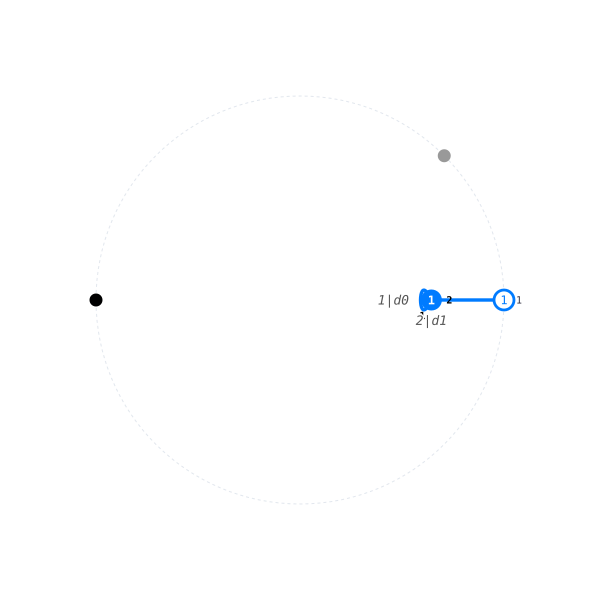

In [11]:
rg = circular(needle_b_graph())
r_needle = only(r for r in CIRCULAR_REGION_RULES if r.name === :needle)
show_circular_step_row(circular_decorated(rg), r_needle.apply(circular_decorated(rg)),
                       CircularMorphismGraph(rg, 0, 0); title = "needle (region)")

braid_relation_region 6 nodes 4 Braids → 5 nodes 3 Braids
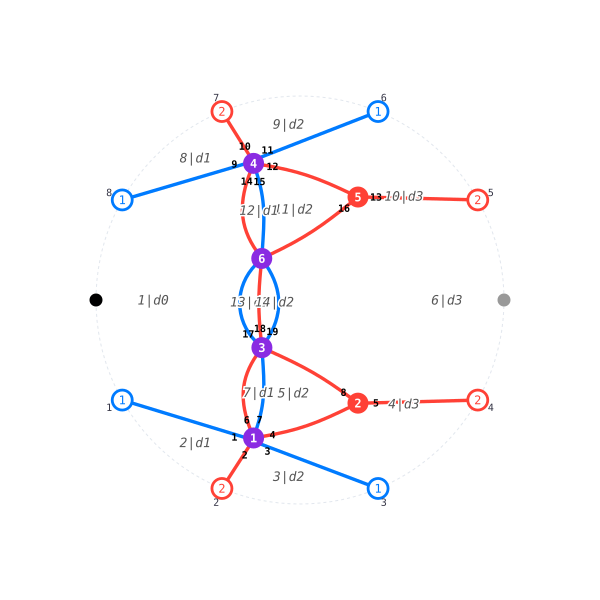
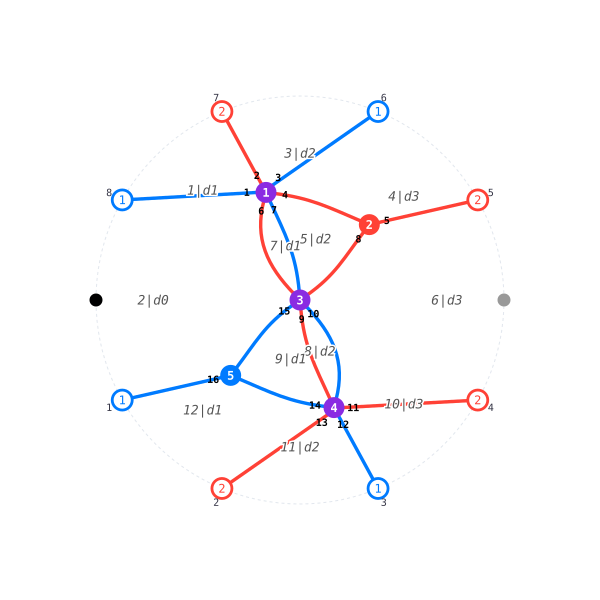

In [12]:
"The first diagram along the reduction of `fm` on which `r` matches."
function walk_to(fm, r)
    cur = circular_decorated(fm.graph)
    for _ in 1:60
        r.apply(cur) === nothing || return cur
        st = circular_step_once(cur, fm)
        st === nothing && return nothing
        ps = collect(pairs_of(st.after))
        length(ps) == 1 || return nothing
        cur = ps[1][1]
    end
    return nothing
end

r_brr = only(r for r in CIRCULAR_REGION_RULES if r.name === :braid_relation_region)
dbr = only(d for d in double_leaves([1,2,1,2], [1,2,1,2]) if d.e == [1,1,1,0] && d.f == [1,1,1,0])
fmbr = circular_morphism(dbr.morphism)
hit = walk_to(fmbr, r_brr)
show_circular_step_row(hit, r_brr.apply(hit), fmbr; title = "braid_relation_region")

## 5. The driver steps

`circular_trace` draws a whole reduction step by step, naming the step that
fired. A double leaf with a dot next to a trivalent goes through D4; a
diagram with two parallel edges goes through 2parallel; the left-hand side
of the first Zamolodchikov rule goes through the Zamo step.

In [13]:
d = double_leaves([1,2,1], [1,2,1])[3]
fm = circular_morphism(d.morphism)
circular_trace(fm.graph, fm)

FIXED POINT after 0 steps:  1 terms, node counts [4]


Step sequence: Symbol[]
Violations (wiring/Euler) across all intermediate results: 0


CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 1 term(s):
  1 · CircularDecorated(CircularGraph(112112, 4 nodes, 5 edges))

Step 1: :2parallel 0 nodes → 1 nodes 1//2*α₁ + 1 nodes 1//2*α₁
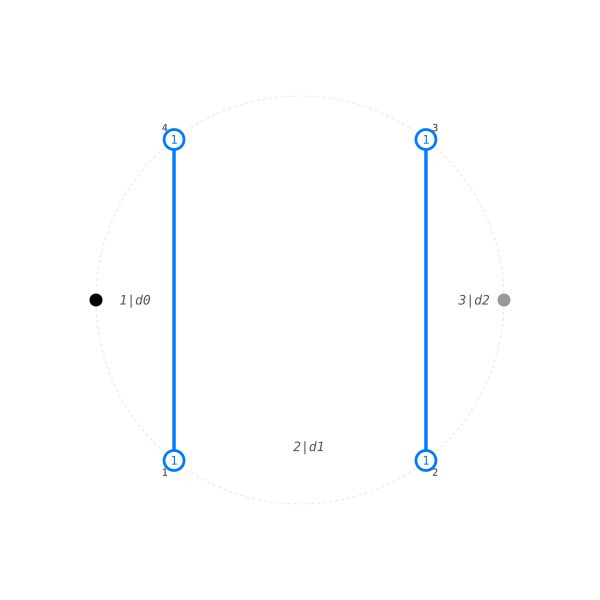
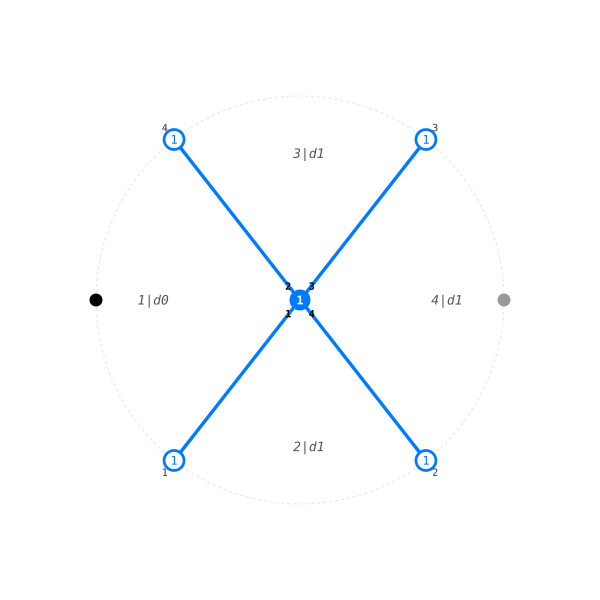
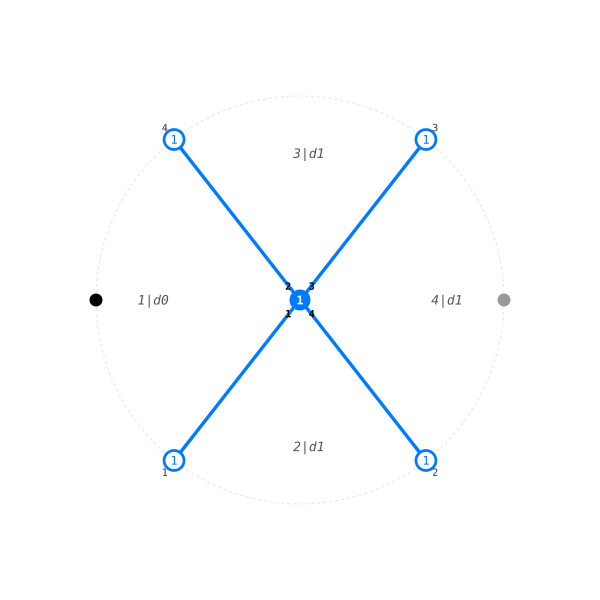

Step 2: :fusion 1 nodes 1//2*α₁ → 1 nodes -1//2*α₁ + 3 nodes
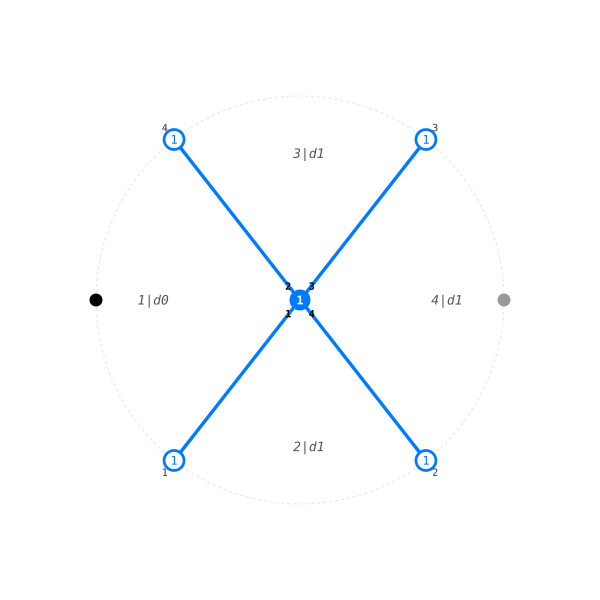
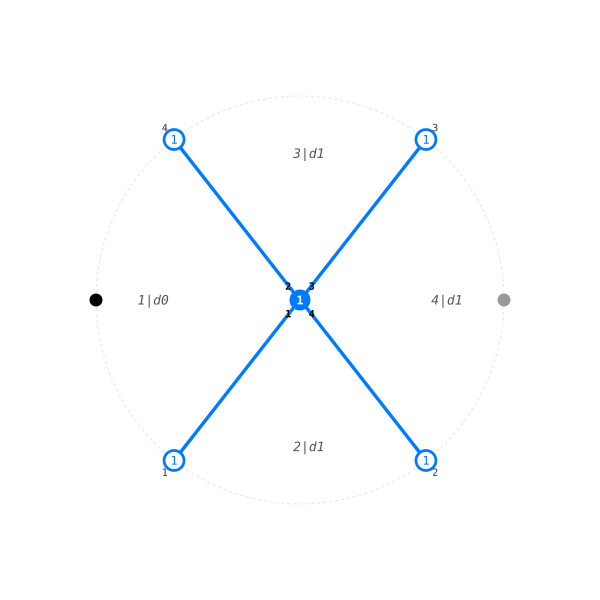
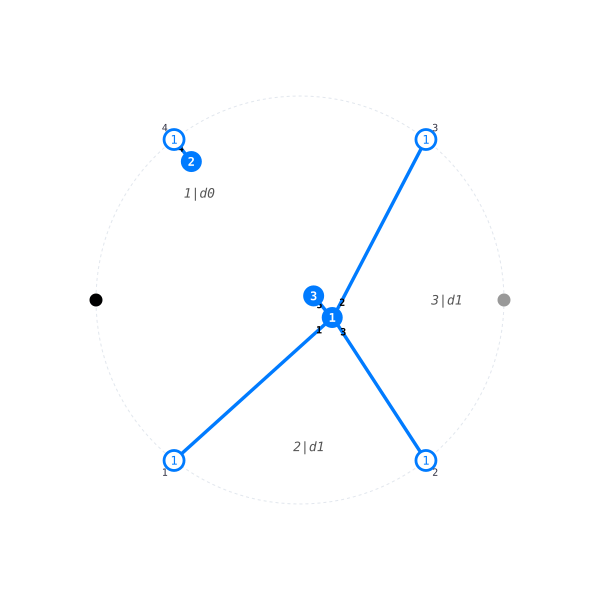

Step 3: :circular_rules 3 nodes → 2 nodes
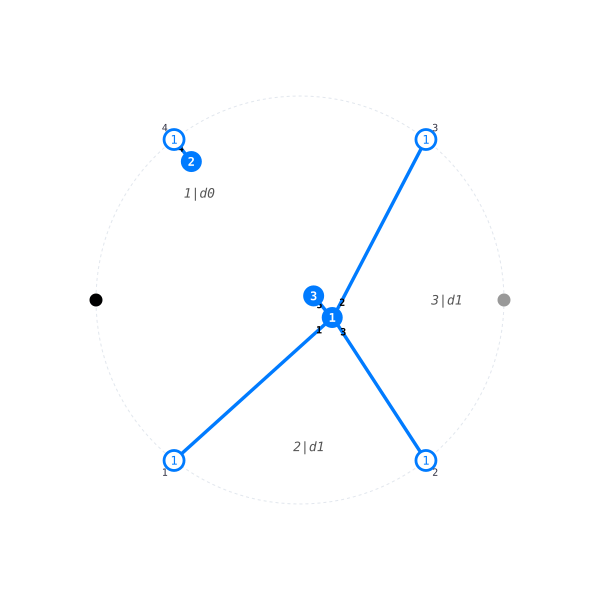
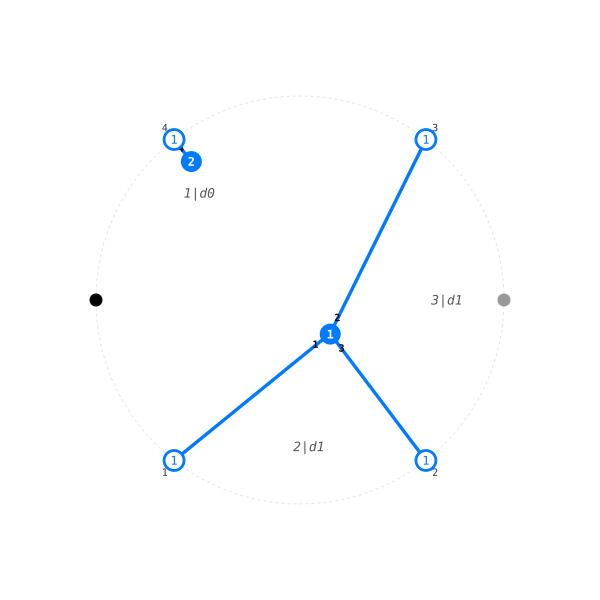

Step 4: :fusion 1 nodes 1//2*α₁ → 1 nodes -1//2*α₁ + 3 nodes
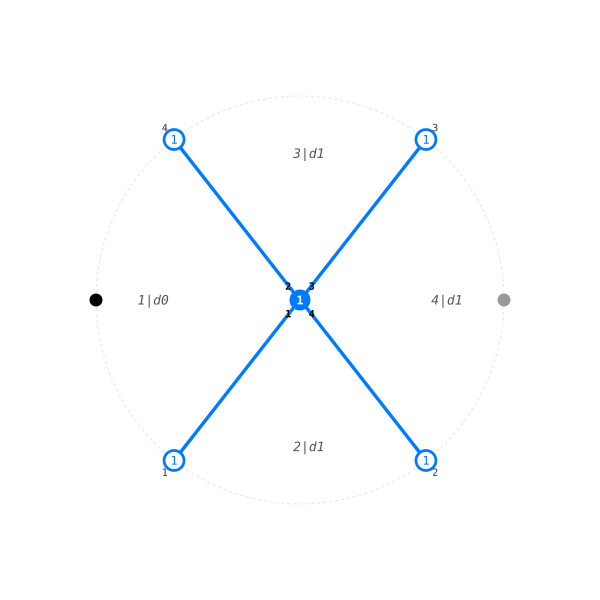
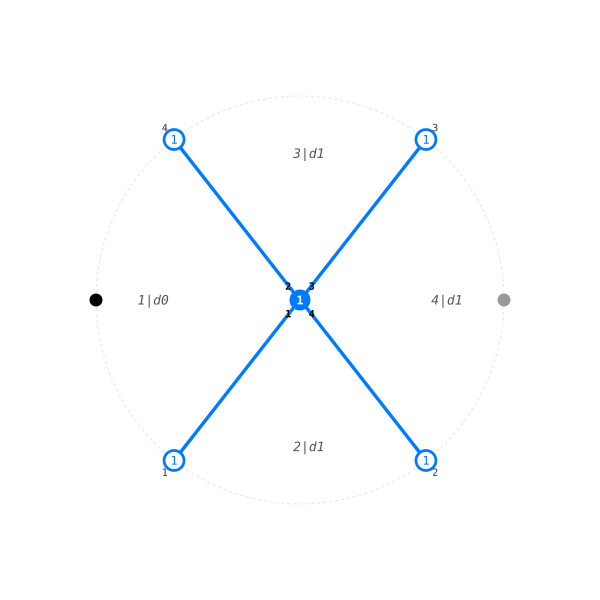
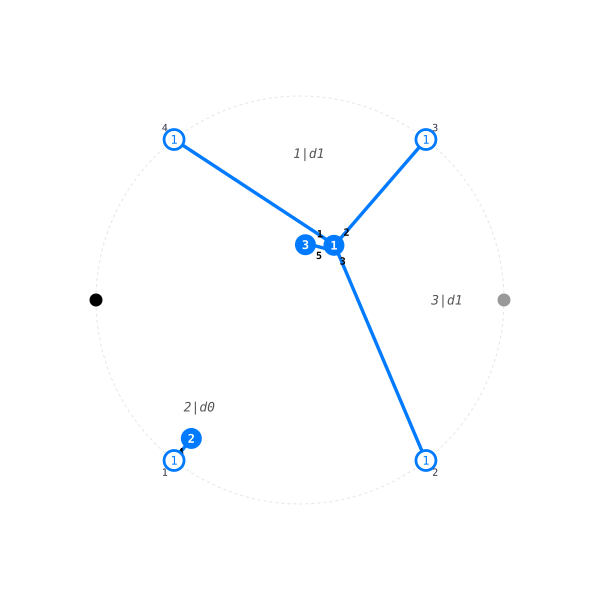

Step 5: :scalars 1 nodes -1//2*α₁ → -1//2*α₁ · 1 nodes
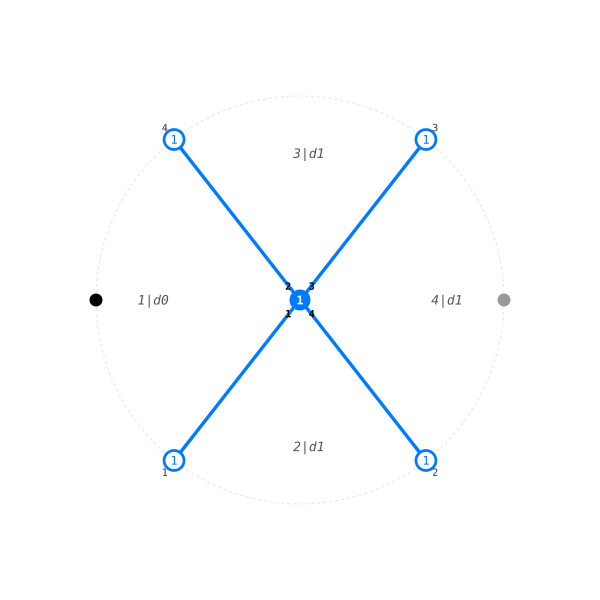
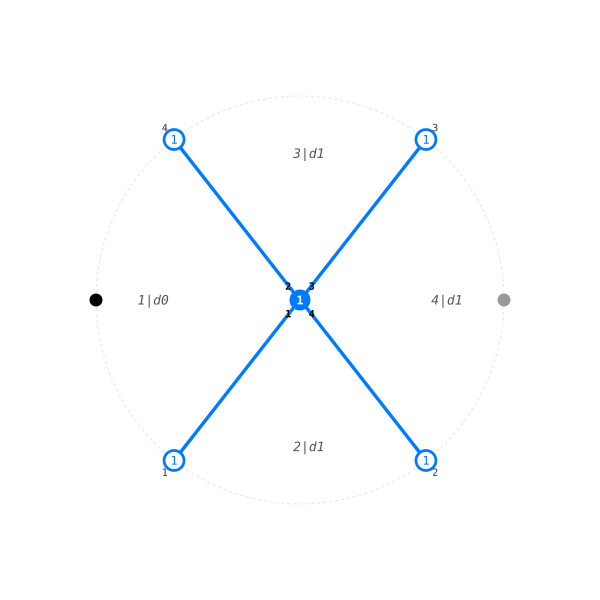

Step 6: :circular_rules 3 nodes → 2 nodes
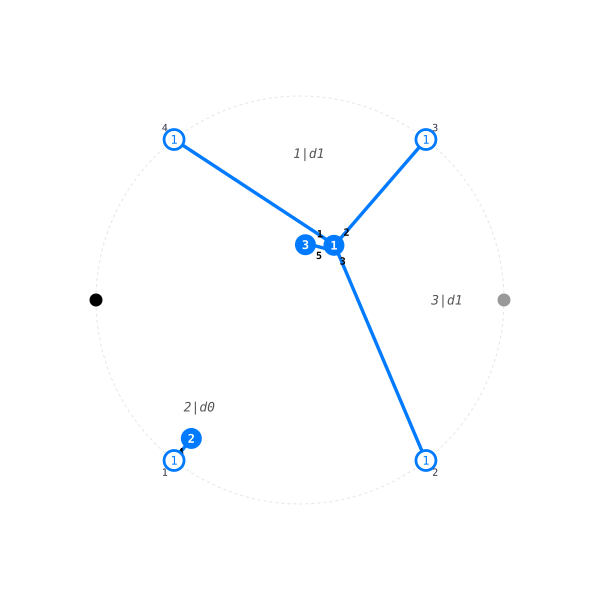
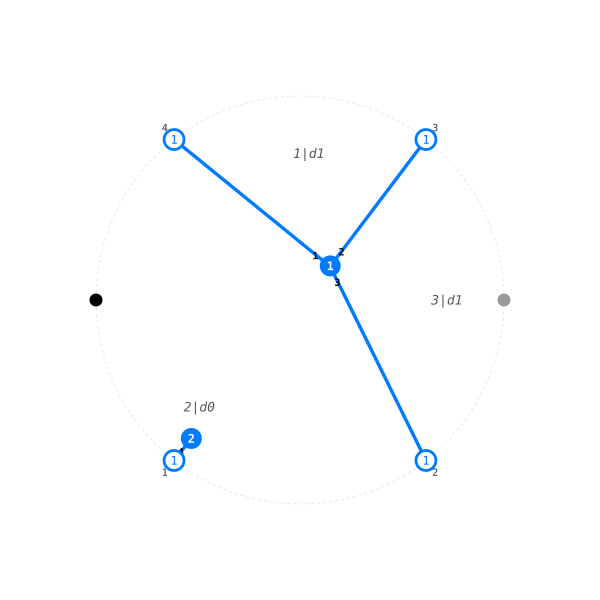

FIXED POINT after 6 steps:  3 terms, node counts [1, 2, 2]
Step sequence: [Symbol("2parallel"), :fusion, :circular_rules, :fusion, :scalars, :circular_rules]
Violations (wiring/Euler) across all intermediate results: 0


CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 3 term(s):
  -α₁ · CircularDecorated(CircularGraph(1111, 1 nodes, 4 edges))
  1 · CircularDecorated(CircularGraph(1111, 2 nodes, 4 edges))
  1 · CircularDecorated(CircularGraph(1111, 2 nodes, 4 edges))

In [14]:
par = CircularGraph(CircularWord([1, 1, 1, 1]), CircularNode[],
                    Edge[Edge(1, Leaf(1), Leaf(4)), Edge(1, Leaf(2), Leaf(3))])
circular_trace(par, CircularMorphismGraph(par, 0, 2))

Step 1: :zamo 7 nodes 4 Braids → 7 nodes 4 Braids
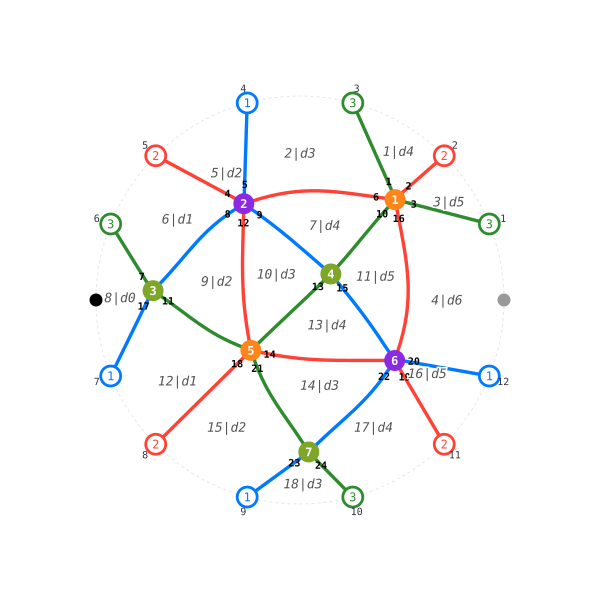
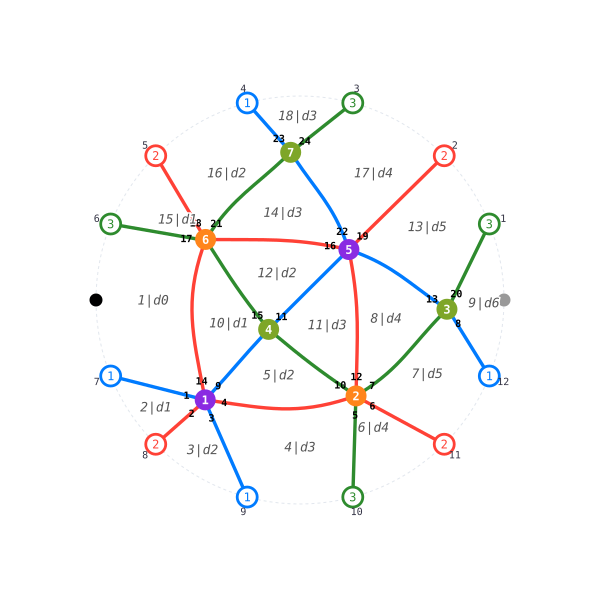

FIXED POINT after 1 steps:  1 terms, node counts [7]
Step sequence: [:zamo]
Violations (wiring/Euler) across all intermediate results: 0


CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 1 term(s):
  1 · CircularDecorated(CircularGraph(121321323123, 7 nodes, 24 edges))

In [15]:
z = flip(Zamo(8, 1))                       # the left-hand side of Z1
fz = circular_morphism(z)
circular_trace(fz.graph, fz; steps = circular_steps(:zamo))

Rex fusion and dot fusion are the two `:after_d4` stages. They do not sit in
`CIRCULAR_RULES` — they are steps of `reduce_to_circular_leave`, listed in
`CIRCULAR_STEPS`. `213213`, a reduced word for the longest element, produces a
double leaf on which the rex fusion fires.

In [16]:
wrx = [2,1,3,2,1,3]
@show is_reduced(wrx)
drx = only(d for d in double_leaves(wrx, wrx) if d.e == [0,1,1,0,1,0] && d.f == [0,1,1,0,1,0])
fmrx = circular_morphism(drx.morphism)
circular_trace(fmrx.graph, fmrx; steps = circular_steps(:rex_fusion), maxsteps = 4)

is_reduced(wrx) = true


FIXED POINT after 0 steps:  1 terms, node counts [8]
Step sequence: Symbol[]
Violations (wiring/Euler) across all intermediate results: 0


CircularCombo{AbstractAlgebra.Generic.MPoly{Rational{BigInt}}} with 1 term(s):
  1 · CircularDecorated(CircularGraph(122132133123, 8 nodes, 15 edges))